# **Método da descida do gradiente (gradient descent)**<br>

SME0829 - Aprendizado de Máquina<br>
Francisco A. Rodrigues<br>
ICMC-USP

## Regressão linear simples

Vamos considerar a regressão linear simples:

beta0 = -0.9494488934269667
beta1 = 2.18599815406887


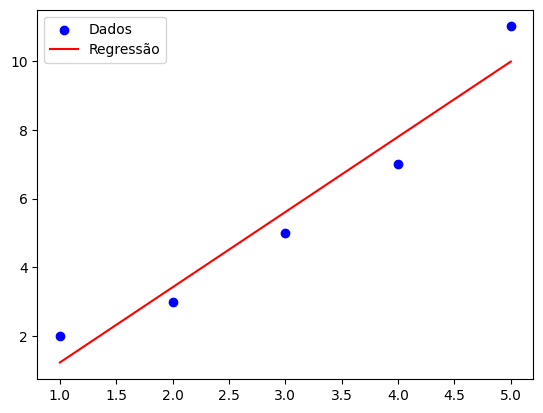

Previsão para x=6: [12.16654003]


In [116]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dados
# -----------------------------
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 7, 11])

n = len(x)

# -----------------------------
# Inicialização
# -----------------------------
beta0 = 0.0
beta1 = 0.0

alpha = 0.01 #taxa de aprendizado
epochs = 1000

# -----------------------------
# Treinamento
# -----------------------------
for epoch in range(epochs):
    y_hat = beta0 + beta1 * x

    erro = y - y_hat

    # Gradientes
    d_beta0 = (-2/n) * np.sum(erro)
    d_beta1 = (-2/n) * np.sum(erro * x)

    # Atualização
    beta0 -= alpha * d_beta0
    beta1 -= alpha * d_beta1

# -----------------------------
# Resultado
# -----------------------------
print("beta0 =", beta0)
print("beta1 =", beta1)

# -----------------------------
# Visualização
# -----------------------------
plt.scatter(x, y, color='blue', label='Dados')
plt.plot(x, beta0 + beta1 * x, color='red', label='Regressão')
plt.legend()
plt.show()

# You can also make a prediction if needed
x_new_sk = np.array([[6]]) # Example new data point
y_pred_sk = beta0 + beta1 * x_new_sk
print(f"Previsão para x={x_new_sk[0][0]}:", y_pred_sk[0])

Usando o scikit-learn:

Parâmetros estimados (scikit-learn):
Intercept (beta0): -1.0000000000000018
Coefficient (beta1): 2.2000000000000006


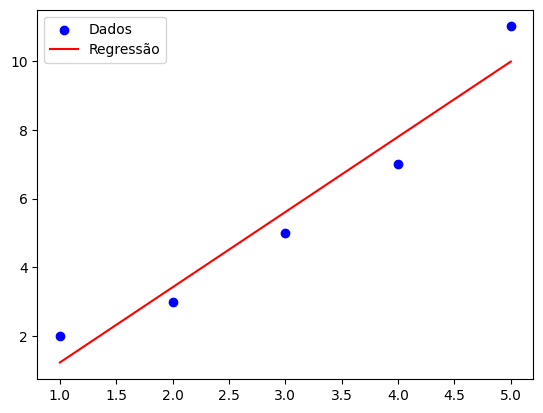

Previsão para x=6: 12.200000000000001


In [117]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Using the x and y data from the previous cell (zR8po7SSY6ty)
x_sk = x.reshape(-1, 1)  # Reshape x to be a 2D array for scikit-learn
y_sk = y

# Initialize and fit the model
model_sk = LinearRegression()
model_sk.fit(x_sk, y_sk)

# Print the estimated parameters (intercept and coefficient)
print("Parâmetros estimados (scikit-learn):")
print("Intercept (beta0):", model_sk.intercept_)
print("Coefficient (beta1):", model_sk.coef_[0])


# -----------------------------
# Visualização
# -----------------------------
plt.scatter(x, y, color='blue', label='Dados')
plt.plot(x, beta0 + beta1 * x, color='red', label='Regressão')
plt.legend()
plt.show()

# You can also make a prediction if needed
x_new_sk = np.array([[6]]) # Example new data point
y_pred_sk = model_sk.predict(x_new_sk)
print(f"Previsão para x={x_new_sk[0][0]}:", y_pred_sk[0])

## Regressão múltipla

In [118]:
import numpy as np

# -----------------------------
# Dados (com intercepto)
# -----------------------------
X = np.array([
    [1, 1, 2],
    [1, 2, 1],
    [1, 3, 3],
    [1, 4, 5]
])

y = np.array([5, 6, 9, 13])

n, p = X.shape

# -----------------------------
# Inicialização
# -----------------------------
beta = np.zeros(p)
alpha = 0.01
epochs = 1000

# -----------------------------
# Treinamento (gradiente)
# -----------------------------
for epoch in range(epochs):
    y_hat = X @ beta
    erro = y - y_hat

    grad = (-2/n) * X.T @ erro

    beta = beta - alpha * grad

# -----------------------------
# Resultado
# -----------------------------
print("Parâmetros estimados:")
print(beta)

# -----------------------------
# Previsão
# -----------------------------
x_novo = np.array([1, 2, 2])
y_pred = x_novo @ beta

print("Previsão para x_novo:", y_pred)

Parâmetros estimados:
[1.46529729 1.73868199 0.88470609]
Previsão para x_novo: 6.712073453089271


Usando o scikit-learn:

In [119]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the model (fit_intercept=False because X already has an intercept column)
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

# Print the estimated parameters (coefficients)
print("Parâmetros estimados (scikit-learn):")
print(model.coef_)

# Make a prediction for x_novo
y_pred_sk = model.predict(x_novo.reshape(1, -1))
print("Previsão para x_novo (scikit-learn):")
print("Previsão para x_novo:", y_pred_sk[0])

Parâmetros estimados (scikit-learn):
[1.5        1.72222222 0.88888889]
Previsão para x_novo (scikit-learn):
Previsão para x_novo: 6.722222222222221


## Regressão logística

beta0 = -15.285514880547476
beta1 = 4.4105195831390835


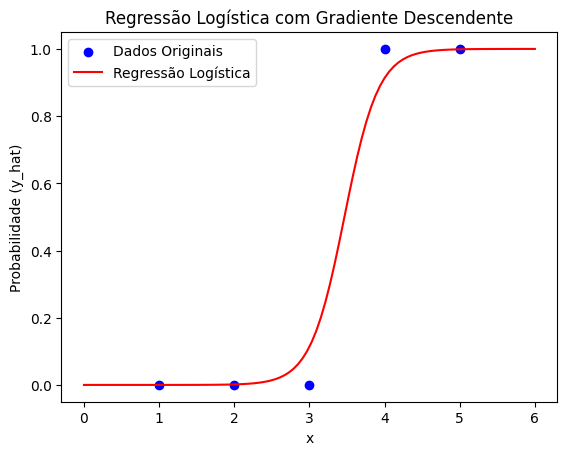

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dados (classificação binária)
# -----------------------------
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 0, 1, 1])

n = len(x)

# -----------------------------
# Inicialização
# -----------------------------
beta0 = 0.0
beta1 = 0.0

alpha = 0.05
epochs = 20000

# Função sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# Treinamento
# -----------------------------
for epoch in range(epochs):
    z = beta0 + beta1 * x
    y_hat = sigmoid(z)

    erro = y_hat - y

    d_beta0 = (1/n) * np.sum(erro)
    d_beta1 = (1/n) * np.sum(erro * x)

    beta0 -= alpha * d_beta0
    beta1 -= alpha * d_beta1

print("beta0 =", beta0)
print("beta1 =", beta1)

# Mostra os resultados ######
# Gerar pontos para a curva sigmoide
x_plot = np.linspace(x.min() - 1, x.max() + 1, 100)
z_plot = beta0 + beta1 * x_plot
y_plot = sigmoid(z_plot)

# Plotar os dados originais
plt.scatter(x, y, color='blue', label='Dados Originais')

# Plotar a curva sigmoide ajustada
plt.plot(x_plot, y_plot, color='red', label='Regressão Logística')

plt.xlabel('x')
plt.ylabel('Probabilidade (y_hat)')
plt.title('Regressão Logística com Gradiente Descendente')
plt.legend()
plt.grid(False)
plt.show()

/home/leftlu/Área de trabalho/USP/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


beta0 = -61.58973205862714
beta1 = 17.553892589113538


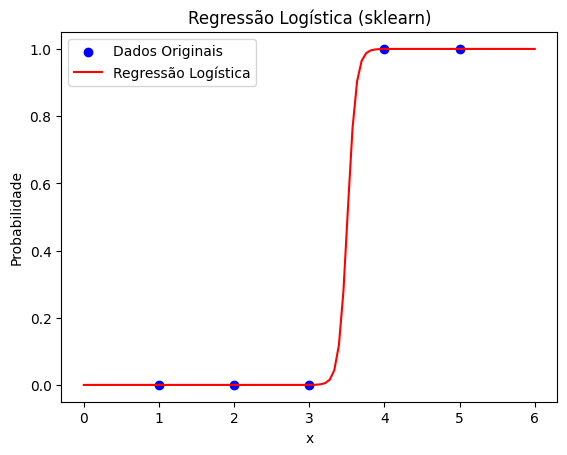

In [121]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# -----------------------------
# Dados
# -----------------------------
x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([0, 0, 0, 1, 1])

# -----------------------------
# Modelo
# -----------------------------
model = LogisticRegression(
    penalty=None,        # sem regularização
    solver="lbfgs"       # método de otimização
)

model.fit(x, y)

# -----------------------------
# Parâmetros estimados
# -----------------------------
beta1 = model.coef_[0][0]
beta0 = model.intercept_[0]

print("beta0 =", beta0)
print("beta1 =", beta1)

# -----------------------------
# Probabilidades previstas
# -----------------------------
x_plot = np.linspace(x.min() - 1, x.max() + 1, 100).reshape(-1, 1)
y_plot = model.predict_proba(x_plot)[:, 1]

# -----------------------------
# Plot
# -----------------------------
plt.scatter(x, y, color='blue', label='Dados Originais')
plt.plot(x_plot, y_plot, color='red', label='Regressão Logística')

plt.xlabel('x')
plt.ylabel('Probabilidade')
plt.title('Regressão Logística (sklearn)')
plt.legend()
plt.grid(False)
plt.show()

## Dados

Parâmetros estimados:
beta0 = -9.446259210976411
beta1 = 3.663828691125811
Fronteira de decisão x* = 2.578248058883395
Acurácia = 1.0


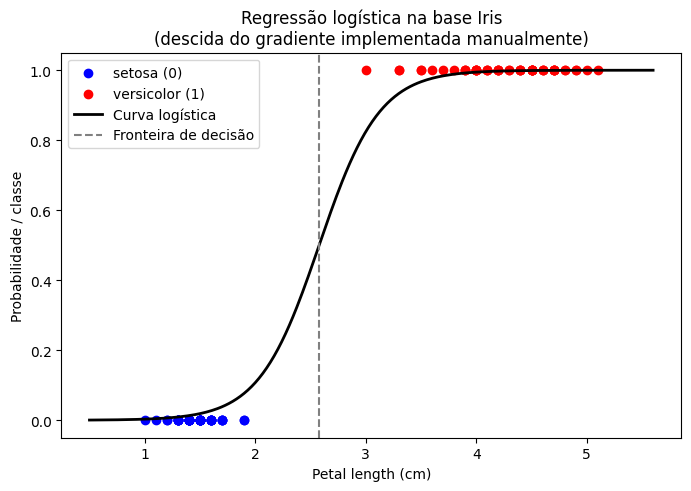

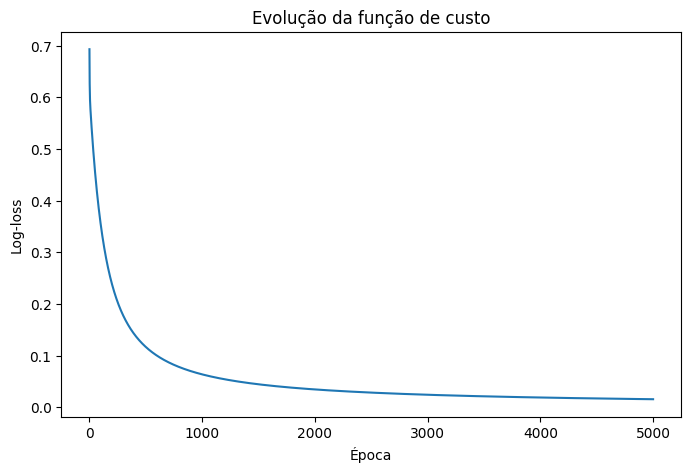

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# =========================================================
# 1. Carregar os dados da Iris
# =========================================================
iris = load_iris()

# Vamos usar apenas duas classes:
# 0 = setosa
# 1 = versicolor
X_all = iris.data
y_all = iris.target

mask = y_all < 2
X_all = X_all[mask]
y = y_all[mask]

# =========================================================
# 2. Escolher uma única variável
# Aqui usamos petal length (cm), que é a coluna 2
# =========================================================
x = X_all[:, 2]

# =========================================================
# 3. Função sigmoide
# =========================================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# =========================================================
# 4. Inicialização
# =========================================================
n = len(x)

beta0 = 0.0
beta1 = 0.0

alpha = 0.1
epochs = 5000

# Para armazenar o valor da função de custo
cost_history = []

# =========================================================
# 5. Treinamento por descida do gradiente
# =========================================================
for epoch in range(epochs):
    z = beta0 + beta1 * x
    y_hat = sigmoid(z)

    erro = y_hat - y

    # Gradientes
    d_beta0 = (1 / n) * np.sum(erro)
    d_beta1 = (1 / n) * np.sum(erro * x)

    # Atualização
    beta0 -= alpha * d_beta0
    beta1 -= alpha * d_beta1

    # Cálculo da log-loss
    eps = 1e-10
    cost = -(1 / n) * np.sum(
        y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
    )
    cost_history.append(cost)

# =========================================================
# 6. Resultados
# =========================================================
print("Parâmetros estimados:")
print("beta0 =", beta0)
print("beta1 =", beta1)

# Fronteira de decisão: beta0 + beta1*x = 0
x_decisao = -beta0 / beta1
print("Fronteira de decisão x* =", x_decisao)

# =========================================================
# 7. Classificação final
# =========================================================
y_prob = sigmoid(beta0 + beta1 * x)
y_pred = (y_prob >= 0.5).astype(int)

acuracia = np.mean(y_pred == y)
print("Acurácia =", acuracia)

# =========================================================
# 8. Gráfico da curva logística
# =========================================================
x_plot = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
y_plot = sigmoid(beta0 + beta1 * x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(x[y == 0], y[y == 0], color="blue", label="setosa (0)")
plt.scatter(x[y == 1], y[y == 1], color="red", label="versicolor (1)")
plt.plot(x_plot, y_plot, color="black", linewidth=2, label="Curva logística")
plt.axvline(x_decisao, color="gray", linestyle="--", label="Fronteira de decisão")

plt.xlabel("Petal length (cm)")
plt.ylabel("Probabilidade / classe")
plt.title("Regressão logística na base Iris\n(descida do gradiente implementada manualmente)")
plt.legend()
plt.grid(False)
plt.show()

# =========================================================
# 9. Gráfico da função de custo
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Época")
plt.ylabel("Log-loss")
plt.title("Evolução da função de custo")
plt.grid(False)
plt.show()

## Exercícios

1 - Ajuste um modelo de regressão linear aos dados a seguir. Compare com o modelo ajustado usando o scikit-learn.

x = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
y = [ 2.14835708  2.73086785  4.02384427  5.36151493  5.38292331  6.28293152
  8.08960641  8.58371736  8.86526281 10.27128002]


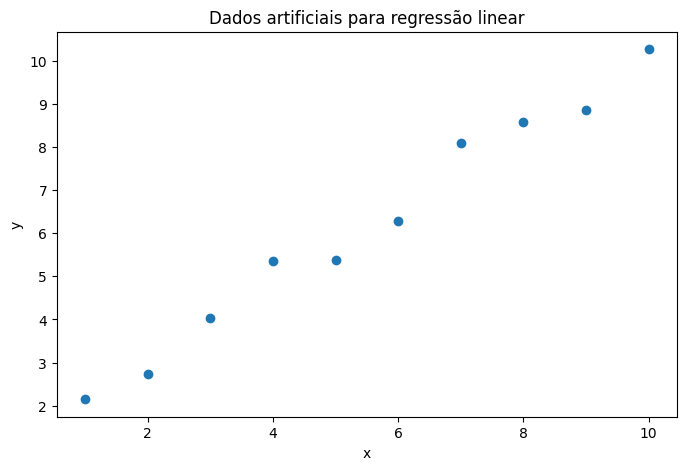

In [123]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Gerar dados artificiais
# -----------------------------
np.random.seed(42)

x = np.linspace(1, 10, 10)
ruido = np.random.normal(0, 0.5, size=len(x))

y = 1 + 0.9 * x + ruido

# -----------------------------
# Mostrar os dados
# -----------------------------
print("x =", x)
print("y =", y)

# -----------------------------
# Plot dos dados
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Dados artificiais para regressão linear")

plt.show()

beta0 = 0.5257381189488546
beta1 = 0.9995786507198657


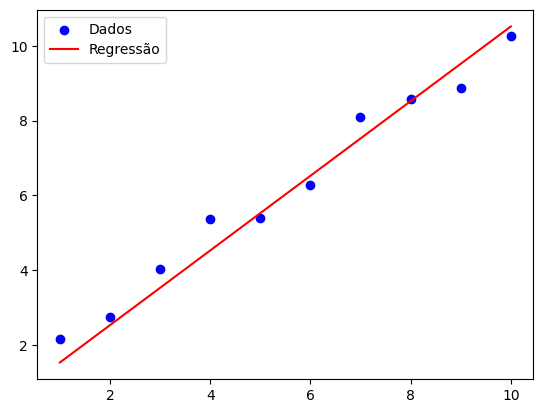

Previsão para x=5: [5.52363137]


In [124]:
###inicializando os coeeficientes do gradiente
beta0 = 0.0
beta1 = 0.0
taxa = 0.01
epocas = 1000

#etapa de treino
for epoca in range(epocas):
    y_hat = beta0 + beta1 * x

    erro = y - y_hat

    # Gradientes
    d_beta0 = (-2/n) * np.sum(erro)
    d_beta1 = (-2/n) * np.sum(erro * x)

    # Atualização
    beta0 -= taxa * d_beta0
    beta1 -= taxa * d_beta1

    # -----------------------------
# Resultado
# -----------------------------
print("beta0 =", beta0)
print("beta1 =", beta1)

# -----------------------------
# Visualização
# -----------------------------
plt.scatter(x, y, color='blue', label='Dados')
plt.plot(x, beta0 + beta1 * x, color='red', label='Regressão')
plt.legend()
plt.show()

# You can also make a prediction if needed
x_new_sk = np.array([[5]]) # Example new data point
y_pred_sk1 = beta0 + beta1 * x_new_sk
print(f"Previsão para x={x_new_sk[0][0]}:", y_pred_sk1[0])

Parâmetros estimados (scikit-learn):
Intercept (beta0): 1.2430065779800517
Coefficient (beta1): 0.8965498141580595


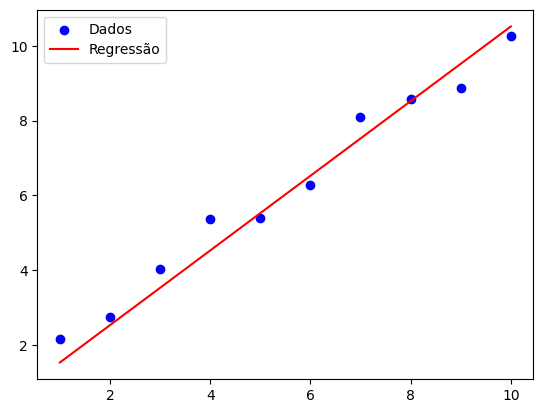

Previsão para x=5: 5.725755648770349


In [125]:
#utilizando o scikit

x_sk = x.reshape(-1, 1)  # Reshape x to be a 2D array for scikit-learn
y_sk = y

# Initialize and fit the model
model_sk = LinearRegression()
model_sk.fit(x_sk, y_sk)

# Print the estimated parameters (intercept and coefficient)
print("Parâmetros estimados (scikit-learn):")
print("Intercept (beta0):", model_sk.intercept_)
print("Coefficient (beta1):", model_sk.coef_[0])


# -----------------------------
# Visualização
# -----------------------------
plt.scatter(x, y, color='blue', label='Dados')
plt.plot(x, beta0 + beta1 * x, color='red', label='Regressão')
plt.legend()
plt.show()

# You can also make a prediction if needed
x_new_sk = np.array([[5]]) # Example new data point
y_pred_sk = model_sk.predict(x_new_sk)
print(f"Previsão para x={x_new_sk[0][0]}:", y_pred_sk[0])

In [126]:
#vendo a diff
print( y_pred_sk1[0] - y_pred_sk[0])

[-0.20212428]


2 - Considere os dados concrete_data.csv e ajuste um modelo de regressão usando a descida do gradiente.

In [127]:
import pandas as pd

In [128]:
data = pd.read_csv("./data/concrete_data.csv")

data.head(5)
data.columns = data.columns.str.strip()

#atributos - 8
X = data[['cement',
          'blast_furnace_slag',
          'fly_ash',
          'water',
          'superplasticizer',
          'coarse_aggregate',
          'fine_aggregate',
          'age']]


#alvo
y = data['concrete_compressive_strength']

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error



In [130]:

scaler = StandardScaler()


# divindindo entre treino e teste
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

#Normalizando 
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# transforma y em numpy
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [131]:
# INTERCEPTO
# ==========================================

x_train = np.c_[np.ones(x_train.shape[0]), x_train]
x_test  = np.c_[np.ones(x_test.shape[0]), x_test]

#Descida do gradiente

n,p = x_train.shape
beta = np.zeros(p)
taxa = 0.001
epocas = 1000

# -----------------------------
# Treinamento (gradiente)
# -----------------------------
for epoca in range(epocas):

    y_hat = x_train @ beta

    erro = y_train - y_hat

    grad = (-2/n) * x_train.T @ erro

    beta = beta - taxa * grad

# -----------------------------
# Resultado
# -----------------------------
print("Parâmetros estimados:")
print(beta)

# -----------------------------
# Previsão
# -----------------------------

y_pred = x_test @ beta

print("\nPrimeiras previsões:")
print(y_pred[:10])

# ==========================================
# ERRO
# ==========================================

mse_manual = mean_squared_error(y_test, y_pred)

print("\nMSE:", mse_manual)


Parâmetros estimados:
[31.26978079  6.12419614  2.73210091 -0.95021785 -4.13576769  4.0509748
 -1.63160786 -2.28292734  5.37856823]

Primeiras previsões:
[50.69028734 44.64604191 58.7124916  44.29682945 15.22247075 34.49066791
 22.36874875 37.95012717 25.42912857 33.87832769]

MSE: 141.11047585533998


In [132]:
model = LinearRegression()
model.fit(x_train, y_train)

# coeficientes
print("Parâmetros estimados (scikit-learn):")
print(model.coef_)

# previsao
y_pred_sk = model.predict(x_test)

#erro
mse_sk = mean_squared_error(y_test, y_pred_sk)

print("\nPrimeira previsão:")
print(y_pred_sk[0])

print("\nMSE Sklearn:")
print(mse_sk)

Parâmetros estimados (scikit-learn):
[ 0.         13.5859155  10.23748839  5.73058513 -1.91518897  2.39568132
  2.20535389  2.91260295  7.01972961]

Primeira previsão:
58.575598249707134

MSE Sklearn:
109.75080797014405


In [133]:
# COMPARAÇÃO


print("\nBeta manual:")
print(beta)

print("\nBeta sklearn:")
print(model.coef_)

print("\nMSE Manual:")
print(mse_manual)

print("\nMSE Sklearn:")
print(mse_sk)


Beta manual:
[31.26978079  6.12419614  2.73210091 -0.95021785 -4.13576769  4.0509748
 -1.63160786 -2.28292734  5.37856823]

Beta sklearn:
[ 0.         13.5859155  10.23748839  5.73058513 -1.91518897  2.39568132
  2.20535389  2.91260295  7.01972961]

MSE Manual:
141.11047585533998

MSE Sklearn:
109.75080797014405


3 - Faça a classificação da base de vertebralcolumn-2C.csv usando regressão logística implementando a descida do gradiente e compare com o uso do scikit-learn.

In [134]:
data = pd.read_csv("./data/vertebralcolumn-2C.csv")

data.head(5)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [135]:
data.columns = data.columns.str.strip()

X = data[['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis']]
y = data['class']
# transforma classes em 0 e 1
y = np.where(y == 'Abnormal', 1, 0)

#Normalizando
scaler = StandardScaler()
X = scaler.fit_transform(X)

# INTERCEPTO
X = np.c_[np.ones(X.shape[0]), X]


# divindindo entre treino e teste
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)



In [136]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [137]:
# INICIALIZAÇÃO


n, p = x_train.shape

beta = np.zeros(p)

alpha = 0.01
epochs = 20000

# FUNÇÃO SIGMOIDE
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# TREINAMENTO

for epoch in range(epochs):

    z = x_train @ beta

    y_hat = sigmoid(z)

    erro = y_hat - y_train

    grad = (1/n) * (x_train.T @ erro)

    beta = beta - alpha * grad

# RESULTADOS

print("Betas estimados:")
print(beta)

# PREVISÃO


probabilidades = sigmoid(x_test @ beta)

y_pred = (probabilidades >= 0.5).astype(int)

# ACURÁCIA

acc = accuracy_score(y_test, y_pred)

print("\nAcurácia:")
print(acc)

Betas estimados:
[ 2.29559438 -0.18958393  0.89379533 -0.15244554 -0.90986134 -1.11762655
  4.52192869]

Acurácia:
0.9032258064516129


In [138]:
#usando o scikit
model = LogisticRegression()

model.fit(x_train, y_train)

# PARÂMETROS
print("Intercepto (beta0):")
print(model.intercept_)

print("\nCoeficientes:")
print(model.coef_)

# PREVISÃO
y_pred = model.predict(x_test)

print("\nPrimeiras previsões:")
print(y_pred[:10])

# ACURÁCIA
acc = accuracy_score(y_test, y_pred)

print("\nAcurácia:")
print(acc)

# MATRIZ DE CONFUSÃO
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

# RELATÓRIO
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Intercepto (beta0):
[1.92063491]

Coeficientes:
[[ 4.57429636e-04 -1.15036670e-01  7.79128620e-01 -9.57337432e-02
  -7.28639488e-01 -9.69557778e-01  3.58439471e+00]]

Primeiras previsões:
[0 1 1 1 1 1 1 1 1 1]

Acurácia:
0.9032258064516129

Matriz de confusão:
[[20  4]
 [ 5 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82        24
           1       0.94      0.93      0.93        69

    accuracy                           0.90        93
   macro avg       0.87      0.88      0.88        93
weighted avg       0.90      0.90      0.90        93

